In [2]:
# =============================================================================
# 셀 1 — 환경 / 경로 / 유틸 + E 전용 파라미터 (regime_v4 재검증)
# =============================================================================
# 목적: SSOT 경로, 공통 유틸, E팩터(수급 제약) 전용 설정 정의
# 산출물: 없음 (설정만)
# 주의: 다른 02_*.ipynb 셀 1과 동일 패턴, 변수명 절대 변경 금지
# =============================================================================

import warnings, pathlib, json, datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

# ── SSOT 경로 ──────────────────────────────────────────────
load_dotenv(pathlib.Path(r"C:\QP2\.env"))
QP2_ROOT  = pathlib.Path(os.getenv("QP2_ROOT", r"C:\QP2"))
DATA_DIR  = QP2_ROOT / "data"
RAW_DIR   = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
META_DIR  = DATA_DIR / "meta"

PATHS = {
    "px_wide":    INTERIM_DIR / "yahoo_adjclose_wide.parquet",
    "prices_long": INTERIM_DIR / "yahoo_prices_long.parquet",
    "fund_q":     INTERIM_DIR / "fundamentals_quarterly.parquet",
    "mktcap_m":   INTERIM_DIR / "mktcap_monthly.parquet",
    "regime":     INTERIM_DIR / "regime_v4.parquet",
    "universe":   META_DIR    / "sp500_universe.parquet",
    "fscore":     INTERIM_DIR / "fscore_signal.parquet",
}

# ── E 팩터 전용 파라미터 ──────────────────────────────────
TOP_N       = 30          # 포트폴리오 종목 수
COST_BP     = 20          # 편도 거래비용 (bp)
REGIME_COL  = "regime"    # 레짐 컬럼 (regime_v4)
EXCLUDE_REGIMES = []  # regime_v4는 3레짐이므로 제외 없음

# P-5 (BAB) 파라미터
BETA_LOOKBACK_DAYS = 252  # 롤링 베타 산출 윈도우 (거래일 기준 ~12M)
BETA_MIN_OBS       = 200  # 최소 관측치
BETA_MARKET        = "ew" # 시장 벤치마크: "ew" (EW) or "spx" (S&P500 지수)

# E-3 (비자발적 수급) 파라미터
REBAL_WINDOW_DAYS  = 5    # 리밸런싱 전후 관찰 윈도우 (거래일)
REVERSION_HORIZON  = 20   # 복원 관찰 기간 (거래일)

# ── 공통 유틸 함수 ─────────────────────────────────────────
def winsorize(s, lower=0.01, upper=0.99):
    """시리즈 윈저라이즈 (양쪽 꼬리 잘라내기)"""
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def zscore_by_date(df, col, group_col="date"):
    """날짜별 횡단면 z-score"""
    g = df.groupby(group_col)[col]
    return (df[col] - g.transform("mean")) / g.transform("std")

def calc_perf(ret_series, cost_bp=0, turnover=0):
    """
    월간 수익률 시리즈 → CAGR, Sharpe, MaxDD 계산
    cost_bp: 편도 거래비용(bp), turnover: 월 회전율 (0~1)
    """
    r = ret_series.dropna()
    if len(r) < 12:
        return {"CAGR": np.nan, "Sharpe": np.nan, "MaxDD": np.nan, "months": len(r)}
    # 거래비용 차감
    net = r - (cost_bp / 10000) * 2 * turnover
    cum = (1 + net).cumprod()
    total_years = len(net) / 12
    cagr = cum.iloc[-1] ** (1 / total_years) - 1
    sharpe = net.mean() / net.std() * np.sqrt(12) if net.std() > 0 else 0
    dd = cum / cum.cummax() - 1
    maxdd = dd.min()
    return {"CAGR": cagr, "Sharpe": sharpe, "MaxDD": maxdd, "months": len(net)}

def calc_tstat(port_ret, bm_ret):
    """포트폴리오 vs 벤치마크 초과수익률 t-stat"""
    excess = port_ret - bm_ret
    excess = excess.dropna()
    if len(excess) < 2:
        return np.nan
    return excess.mean() / (excess.std() / np.sqrt(len(excess)))

print("=" * 60)
print("05_E_P5.ipynb — E팩터 (수급 제약: E-3 + P-5 BAB)")
print(f"QP2_ROOT       : {QP2_ROOT}")
print(f"TOP_N          : {TOP_N}")
print(f"BETA_LOOKBACK  : {BETA_LOOKBACK_DAYS}일")
print(f"BETA_MARKET    : {BETA_MARKET}")
print(f"REGIME_COL     : {REGIME_COL}")
print("=" * 60)

05_E_P5.ipynb — E팩터 (수급 제약: E-3 + P-5 BAB)
QP2_ROOT       : C:\QP2
TOP_N          : 30
BETA_LOOKBACK  : 252일
BETA_MARKET    : ew
REGIME_COL     : regime


In [3]:
# =============================================================================
# 셀 2 — 데이터 로드
# =============================================================================
# 목적: 주가, 수익률, 레짐, 유니버스 로드 + EW 벤치마크 생성
# 산출물: px_wide, px_m, ret_1m, ret_1d, regime_m, ew_ret, universe, sector_map
# 주의: ret_1d는 일간 수익률 (베타 계산용), ret_1m은 월간 수익률 (백테스트용)
# =============================================================================

# ── 주가 (wide, 일간) ──────────────────────────────────────
px_wide = pd.read_parquet(PATHS["px_wide"])
if "date" in px_wide.columns:
    px_wide = px_wide.set_index("date")
px_wide.index = pd.to_datetime(px_wide.index)
px_wide = px_wide.apply(pd.to_numeric, errors="coerce")

# ── 유니버스 ───────────────────────────────────────────────
universe = pd.read_parquet(PATHS["universe"])
common_tk = sorted(set(universe["ticker_yahoo"]) & set(px_wide.columns))
px_wide = px_wide[common_tk]

# ── 섹터 매핑 ──────────────────────────────────────────────
sector_map = universe.set_index("ticker_yahoo")["GICS Sector"].to_dict()

# ── 일간 수익률 (베타 계산용) ──────────────────────────────
ret_1d = px_wide.pct_change()

# ── 월간 수익률 + 월말 가격 (백테스트용) ───────────────────
px_m = px_wide.resample("ME").last()
ret_1m = px_m.pct_change()

# 분석 시작: 최소 BETA_LOOKBACK_DAYS 이후
start_date = px_wide.index[0] + pd.Timedelta(days=int(BETA_LOOKBACK_DAYS * 1.5))
ret_1m = ret_1m.loc[ret_1m.index >= start_date]
px_m   = px_m.loc[px_m.index >= start_date]

# ── EW 벤치마크 (월간) ─────────────────────────────────────
ew_ret = ret_1m.mean(axis=1)
ew_ret.name = "EW"

# ── 레짐 ───────────────────────────────────────────────────
regime_raw = pd.read_parquet(PATHS["regime"])
regime_raw.index = pd.to_datetime(regime_raw.index)

# regime_v4는 이미 월말 — 리샘플 불필요
regime_m = regime_raw[[REGIME_COL, "bear_phase"]].reindex(ret_1m.index, method="ffill")

print(f"Bear 내부  : {regime_raw[regime_raw['regime']=='Bear']['bear_phase'].value_counts().to_dict()}")

print(f"px_wide     : {px_wide.shape[0]} days × {px_wide.shape[1]} tickers")
print(f"ret_1d      : {ret_1d.shape[0]} days × {ret_1d.shape[1]} tickers")
print(f"ret_1m      : {ret_1m.shape[0]} months × {ret_1m.shape[1]} tickers")
print(f"분석 기간   : {ret_1m.index[0].strftime('%Y-%m-%d')} ~ {ret_1m.index[-1].strftime('%Y-%m-%d')}")
print(f"EW BM       : {len(ew_ret)} months")
print(f"레짐 분포   :")
print(regime_m[REGIME_COL].value_counts().sort_index().to_string())

Bear 내부  : {'declining': 151, 'recovering': 19}
px_wide     : 16135 days × 503 tickers
ret_1d      : 16135 days × 503 tickers
ret_1m      : 758 months × 503 tickers
분석 기간   : 1963-01-31 ~ 2026-02-28
EW BM       : 758 months
레짐 분포   :
regime
Bear       165
Bull       549
Neutral     44


시장 벤치마크: EW (Equal Weight)
롤링 베타 계산 중... (window=252, min_obs=200)


Beta calc: 100%|██████████| 11/11 [00:01<00:00,  9.60it/s]



beta_wide   : 758 months × 503 tickers
beta_long   : 202,871 rows

베타 분포 (전체 기간 평균):
  mean  : 1.045
  std   : 0.359
  min   : 0.342
  max   : 4.436
  Q1/Q3 : 0.823 / 1.236


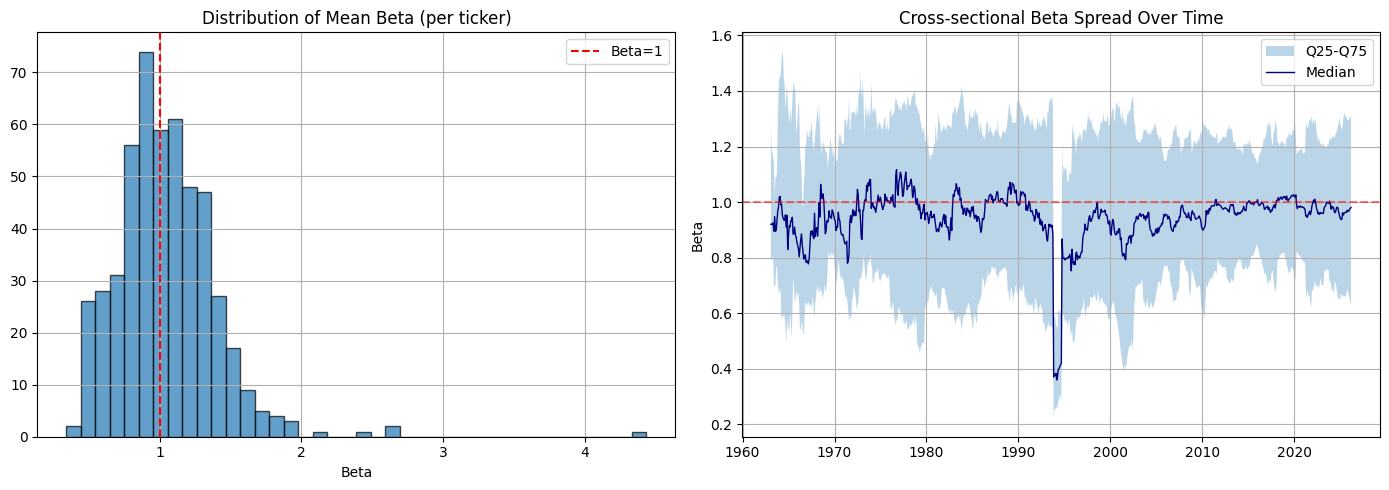

In [4]:
# =============================================================================
# 셀 3 — P-5: 롤링 베타 계산
# =============================================================================
# 목적: 각 종목의 시장 대비 롤링 베타 산출 (12M 윈도우)
# 산출물: beta_wide (월말 × ticker), beta_long (date, ticker, beta)
# 주의: 베타 = Cov(Ri, Rm) / Var(Rm), 최소 관측치 BETA_MIN_OBS 미만이면 NaN
# =============================================================================
from tqdm import tqdm

# ── 시장 수익률 정의 ───────────────────────────────────────
if BETA_MARKET == "ew":
    mkt_ret_d = ret_1d.mean(axis=1)  # 일간 EW
    print("시장 벤치마크: EW (Equal Weight)")
else:
    # S&P500 지수가 있다면 여기서 로드
    mkt_ret_d = ret_1d.mean(axis=1)
    print("시장 벤치마크: EW (fallback)")

# ── 롤링 베타 계산 (벡터화) ────────────────────────────────
# 방법: 롤링 공분산 / 롤링 분산
# pandas rolling으로 한방에 처리

window = BETA_LOOKBACK_DAYS
min_obs = BETA_MIN_OBS

# 시장 분산 (롤링)
mkt_var = mkt_ret_d.rolling(window, min_periods=min_obs).var()

# 각 종목별 시장과의 공분산 (롤링)
print(f"롤링 베타 계산 중... (window={window}, min_obs={min_obs})")

# 효율적 계산: 모든 종목 한번에
# Cov(Ri, Rm) = E[Ri*Rm] - E[Ri]*E[Rm]
# 직접 rolling.cov 사용
beta_daily = pd.DataFrame(index=ret_1d.index, columns=ret_1d.columns, dtype=float)

# 청크 방식으로 메모리 절약하면서 tqdm 표시
chunk_size = 50
tickers = list(ret_1d.columns)

for i in tqdm(range(0, len(tickers), chunk_size), desc="Beta calc"):
    chunk_tk = tickers[i:i+chunk_size]
    for tk in chunk_tk:
        cov_series = ret_1d[tk].rolling(window, min_periods=min_obs).cov(mkt_ret_d)
        beta_daily[tk] = cov_series / mkt_var

# ── 월말 스냅샷 ───────────────────────────────────────────
beta_wide = beta_daily.resample("ME").last()
beta_wide = beta_wide.loc[ret_1m.index[0]:ret_1m.index[-1]]

# ── long format 변환 ──────────────────────────────────────
beta_long = beta_wide.stack().reset_index()
beta_long.columns = ["date", "ticker", "beta"]
beta_long = beta_long.dropna(subset=["beta"])

# ── 요약 통계 ─────────────────────────────────────────────
print(f"\nbeta_wide   : {beta_wide.shape[0]} months × {beta_wide.shape[1]} tickers")
print(f"beta_long   : {len(beta_long):,} rows")
print(f"\n베타 분포 (전체 기간 평균):")
beta_mean = beta_wide.mean()
print(f"  mean  : {beta_mean.mean():.3f}")
print(f"  std   : {beta_mean.std():.3f}")
print(f"  min   : {beta_mean.min():.3f}")
print(f"  max   : {beta_mean.max():.3f}")
print(f"  Q1/Q3 : {beta_mean.quantile(0.25):.3f} / {beta_mean.quantile(0.75):.3f}")

# ── 베타 분포 시각화 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 종목별 평균 베타 히스토그램
axes[0].hist(beta_mean.dropna(), bins=40, edgecolor="black", alpha=0.7)
axes[0].axvline(1.0, color="red", linestyle="--", label="Beta=1")
axes[0].set_title("Distribution of Mean Beta (per ticker)")
axes[0].set_xlabel("Beta")
axes[0].legend()

# 우: 시간에 따른 횡단면 베타 스프레드
beta_q25 = beta_wide.quantile(0.25, axis=1)
beta_q75 = beta_wide.quantile(0.75, axis=1)
beta_med = beta_wide.median(axis=1)

axes[1].fill_between(beta_wide.index, beta_q25, beta_q75, alpha=0.3, label="Q25-Q75")
axes[1].plot(beta_wide.index, beta_med, color="navy", linewidth=1, label="Median")
axes[1].axhline(1.0, color="red", linestyle="--", alpha=0.5)
axes[1].set_title("Cross-sectional Beta Spread Over Time")
axes[1].set_ylabel("Beta")
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# =============================================================================
# 셀 3-1 — 베타 계산 결과 해석
# =============================================================================
#
# ─── 롤링 베타란? ──────────────────────────────────────────────────────
#   각 월말 시점에서 과거 252 거래일(≈1년)의 일간 수익률로 베타 추정
#   매달 윈도우가 한 달씩 밀리면서 업데이트
#   베타 = Cov(종목, 시장) / Var(시장)
#   시장 벤치마크: EW (Equal Weight, 전종목 동일비중)
#
# ─── 베타 분포 해석 ────────────────────────────────────────────────────
#   mean  1.045  : EW 벤치마크 기준이라 1에 수렴하는 게 정상
#   std   0.359  : 종목 간 편차. S&P500 대형주끼리라 스프레드 좁음
#   Q1/Q3 0.82 / 1.24 : 중간 50% 종목이 이 범위 안에 있음
#     → 저베타 Top30 ≈ 0.3~0.7대, 고베타 Top30 ≈ 1.5~2.0+대
#     → BAB로 벌 수 있는 스프레드 폭이 구조적으로 좁다는 뜻
#   max   4.44  : 극단치. 변동성 큰 소수 종목
#
# ─── 히스토그램 (왼쪽) ─────────────────────────────────────────────────
#   종목별 평균 베타 분포
#   대부분 0.5~1.5 사이에 집중, 베타 1 근처가 최빈값
#   오른쪽 꼬리 김 → 고베타 극단치 소수 존재
#   S&P500이 전부 대형주라서 분포가 좁게 몰려있음
#     (소형주 포함 전체 시장이었으면 0.2~3.0까지 넓게 퍼졌을 것)
#
# ─── 시계열 차트 (오른쪽) ──────────────────────────────────────────────
#   파란 밴드: Q25~Q75 (중간 50% 범위), 남색 선: 중위수
#
#   1960~1990년대 초반: 베타가 전체적으로 낮고 흔들림
#     → 당시 유니버스 종목 수 적음 + EW 벤치마크 자체가 불안정
#   2000년대 이후: 중위수 1.0 근처 안정, 밴드 폭 일정
#     → 횡단면 스프레드가 구조적으로 좁다는 의미
#
#   핵심: 밴드 폭이 시간에 따라 크게 변하지 않음
#     = S&P500 내 종목 간 베타 차이가 항상 좁음
#     = BAB가 먹힐 여지가 구조적으로 제한됨
#     → P-5 탈락의 시각적 근거
#
# =============================================================================

P-5 BAB — 전체 기간 성과
                    CAGR   Sharpe    MaxDD   t-stat
----------------------------------------------------------------------
Low Beta (롱)      14.25%    1.083  -36.94%   -2.216
High Beta         23.72%    0.836  -69.45%
EW BM             18.35%    1.112  -47.12%
L-S Spread       -15.65%   -0.446  -99.99%   -3.088

평균 회전율 (Low Beta): 10.8%
평균 저베타: 0.328, 평균 고베타: 1.967
분석 기간: 1974-01 ~ 2026-02 (626개월)

P-5 BAB — 레짐별 성과 (Low Beta 롱온리 vs EW)
레짐                     months  LowB CAGR    EW CAGR       초과  Sharpe_L  Sharpe_EW   t-stat
-----------------------------------------------------------------------------------------------
Bear                      130    -18.21%    -29.73%  +11.52%    -1.223     -1.582    4.247
Bull                      458     25.36%     37.45%  -12.09%     2.061      2.653   -4.906
Neutral                    38     17.02%     15.97%   +1.05%     1.605      1.087    0.161


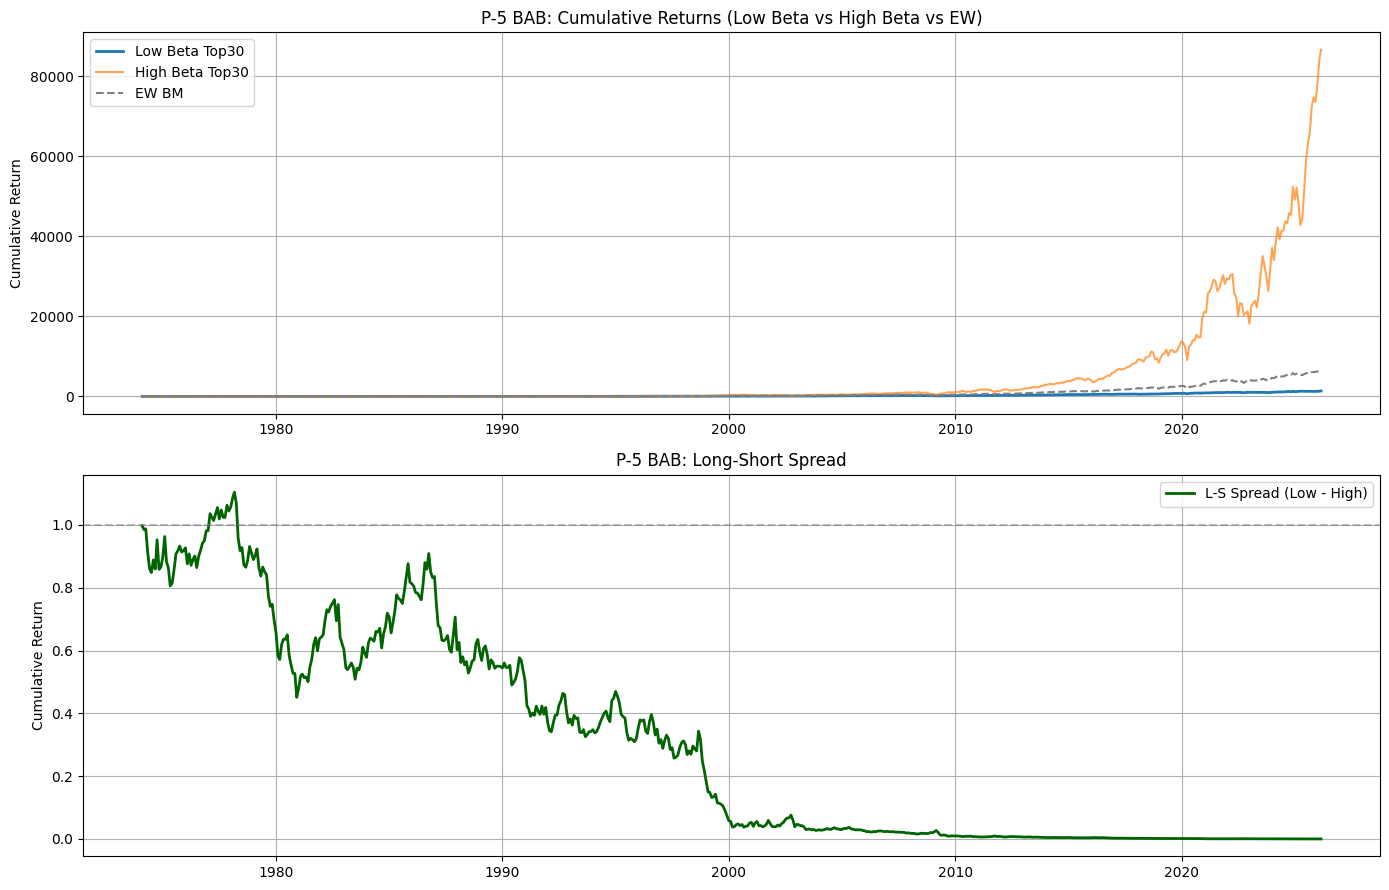

In [6]:
# =============================================================================
# 셀 4 — P-5: BAB 신호 + 단독 백테스트
# =============================================================================
# 목적: 저베타 Top30 롱 포트폴리오 vs 고베타 Top30 + 롱숏 스프레드
#        전체 기간 + 레짐별 성과 측정
# 산출물: bab_result (dict), 레짐별 성과표
# 주의: 원논문은 저베타 레버리지 + 고베타 숏이지만,
#        실전 롱온리 제약 하에서는 저베타 Top30 롱만으로도 검증
# =============================================================================

def backtest_bab(ret_1m, beta_wide, regime_m, top_n=TOP_N, cost_bp=COST_BP):
    """
    P-5 BAB 백테스트
    - 매월 베타 기준 정렬
    - 저베타 Top N (롱), 고베타 Top N (숏 대용)
    - EW 포트폴리오
    """
    dates = sorted(set(ret_1m.index) & set(beta_wide.index))
    
    records = []
    prev_low_set = set()
    prev_high_set = set()
    
    for i, d in enumerate(dates):
        if i == 0:
            continue  # 첫 달은 시그널만, 다음 달부터 수익률
        
        sig_date = dates[i - 1]  # 시그널 기준일 (전월말)
        
        betas = beta_wide.loc[sig_date].dropna()
        if len(betas) < top_n * 2:
            continue
        
        betas_sorted = betas.sort_values()
        low_beta_tks  = list(betas_sorted.head(top_n).index)   # 저베타
        high_beta_tks = list(betas_sorted.tail(top_n).index)   # 고베타
        
        # 수익률
        rets = ret_1m.loc[d]
        low_ret  = rets[low_beta_tks].mean()
        high_ret = rets[high_beta_tks].mean()
        ew = rets.mean()
        
        # 회전율
        low_turnover  = 1 - len(set(low_beta_tks) & prev_low_set) / top_n if prev_low_set else 0
        high_turnover = 1 - len(set(high_beta_tks) & prev_high_set) / top_n if prev_high_set else 0
        
        # 레짐
        reg = regime_m.loc[d, REGIME_COL] if d in regime_m.index else "Unknown"
        
        records.append({
            "date": d,
            "low_beta_ret": low_ret,
            "high_beta_ret": high_ret,
            "spread_ret": low_ret - high_ret,  # BAB: 저베타 롱 - 고베타 숏
            "ew_ret": ew,
            "low_excess": low_ret - ew,
            "high_excess": high_ret - ew,
            "low_turnover": low_turnover,
            "high_turnover": high_turnover,
            "regime": reg,
            "low_beta_mean": betas_sorted.head(top_n).mean(),
            "high_beta_mean": betas_sorted.tail(top_n).mean(),
        })
        
        prev_low_set = set(low_beta_tks)
        prev_high_set = set(high_beta_tks)
    
    return pd.DataFrame(records).set_index("date")


# ── 실행 ──────────────────────────────────────────────────
bab_df = backtest_bab(ret_1m, beta_wide, regime_m)

# ── 전체 기간 성과 ────────────────────────────────────────
avg_turnover = bab_df["low_turnover"].mean()

perf_low  = calc_perf(bab_df["low_beta_ret"], cost_bp=COST_BP, turnover=avg_turnover)
perf_high = calc_perf(bab_df["high_beta_ret"], cost_bp=COST_BP, turnover=avg_turnover)
perf_ew   = calc_perf(bab_df["ew_ret"])
perf_spread = calc_perf(bab_df["spread_ret"], cost_bp=COST_BP, turnover=avg_turnover)

tstat_low  = calc_tstat(bab_df["low_beta_ret"], bab_df["ew_ret"])
tstat_spread = calc_tstat(bab_df["spread_ret"], pd.Series(0, index=bab_df.index))

print("=" * 70)
print("P-5 BAB — 전체 기간 성과")
print("=" * 70)
print(f"{'':15s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print("-" * 70)
print(f"{'Low Beta (롱)':15s} {perf_low['CAGR']:>8.2%} {perf_low['Sharpe']:>8.3f} {perf_low['MaxDD']:>8.2%} {tstat_low:>8.3f}")
print(f"{'High Beta':15s} {perf_high['CAGR']:>8.2%} {perf_high['Sharpe']:>8.3f} {perf_high['MaxDD']:>8.2%}")
print(f"{'EW BM':15s} {perf_ew['CAGR']:>8.2%} {perf_ew['Sharpe']:>8.3f} {perf_ew['MaxDD']:>8.2%}")
print(f"{'L-S Spread':15s} {perf_spread['CAGR']:>8.2%} {perf_spread['Sharpe']:>8.3f} {perf_spread['MaxDD']:>8.2%} {tstat_spread:>8.3f}")
print(f"\n평균 회전율 (Low Beta): {avg_turnover:.1%}")
print(f"평균 저베타: {bab_df['low_beta_mean'].mean():.3f}, 평균 고베타: {bab_df['high_beta_mean'].mean():.3f}")
print(f"분석 기간: {bab_df.index[0].strftime('%Y-%m')} ~ {bab_df.index[-1].strftime('%Y-%m')} ({len(bab_df)}개월)")

# ── 레짐별 성과 ───────────────────────────────────────────
print("\n" + "=" * 70)
print("P-5 BAB — 레짐별 성과 (Low Beta 롱온리 vs EW)")
print("=" * 70)
print(f"{'레짐':22s} {'months':>6s} {'LowB CAGR':>10s} {'EW CAGR':>10s} {'초과':>8s} {'Sharpe_L':>9s} {'Sharpe_EW':>10s} {'t-stat':>8s}")
print("-" * 95)

regime_results = {}
for reg in sorted(bab_df["regime"].unique()):
    if reg in EXCLUDE_REGIMES:
        continue
    mask = bab_df["regime"] == reg
    sub = bab_df.loc[mask]
    if len(sub) < 6:
        continue
    
    p_low = calc_perf(sub["low_beta_ret"], cost_bp=COST_BP, turnover=sub["low_turnover"].mean())
    p_ew  = calc_perf(sub["ew_ret"])
    t     = calc_tstat(sub["low_beta_ret"], sub["ew_ret"])
    excess = p_low["CAGR"] - p_ew["CAGR"]
    
    regime_results[reg] = {"perf_low": p_low, "perf_ew": p_ew, "tstat": t, "months": len(sub)}
    
    print(f"{reg:22s} {len(sub):>6d} {p_low['CAGR']:>10.2%} {p_ew['CAGR']:>10.2%} {excess:>+8.2%} {p_low['Sharpe']:>9.3f} {p_ew['Sharpe']:>10.3f} {t:>8.3f}")

# ── 누적수익률 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

cum_low  = (1 + bab_df["low_beta_ret"]).cumprod()
cum_high = (1 + bab_df["high_beta_ret"]).cumprod()
cum_ew   = (1 + bab_df["ew_ret"]).cumprod()
cum_spread = (1 + bab_df["spread_ret"]).cumprod()

axes[0].plot(cum_low.index, cum_low, label=f"Low Beta Top{TOP_N}", linewidth=2)
axes[0].plot(cum_high.index, cum_high, label=f"High Beta Top{TOP_N}", linewidth=1.5, alpha=0.7)
axes[0].plot(cum_ew.index, cum_ew, label="EW BM", linewidth=1.5, linestyle="--", color="gray")
axes[0].set_title("P-5 BAB: Cumulative Returns (Low Beta vs High Beta vs EW)")
axes[0].legend()
axes[0].set_ylabel("Cumulative Return")

axes[1].plot(cum_spread.index, cum_spread, label="L-S Spread (Low - High)", color="darkgreen", linewidth=2)
axes[1].axhline(1.0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title("P-5 BAB: Long-Short Spread")
axes[1].legend()
axes[1].set_ylabel("Cumulative Return")

plt.tight_layout()
plt.show()

E-3 리밸런싱 충격 계산 중...
e3_raw: 387,310 rows, 770 months

E-3 충격 분포:
count    387310.000000
mean          0.000247
std           0.008984
min          -1.300650
25%          -0.000595
50%           0.000000
75%           0.000609
max           1.771863

분기말 비중: 33.2%
e3_z 분포:
count    3.873100e+05
mean     8.851743e-19
std      9.990068e-01
min     -2.229499e+01
25%     -2.621239e-01
50%     -1.281439e-02
75%      2.772199e-01
max      2.221919e+01


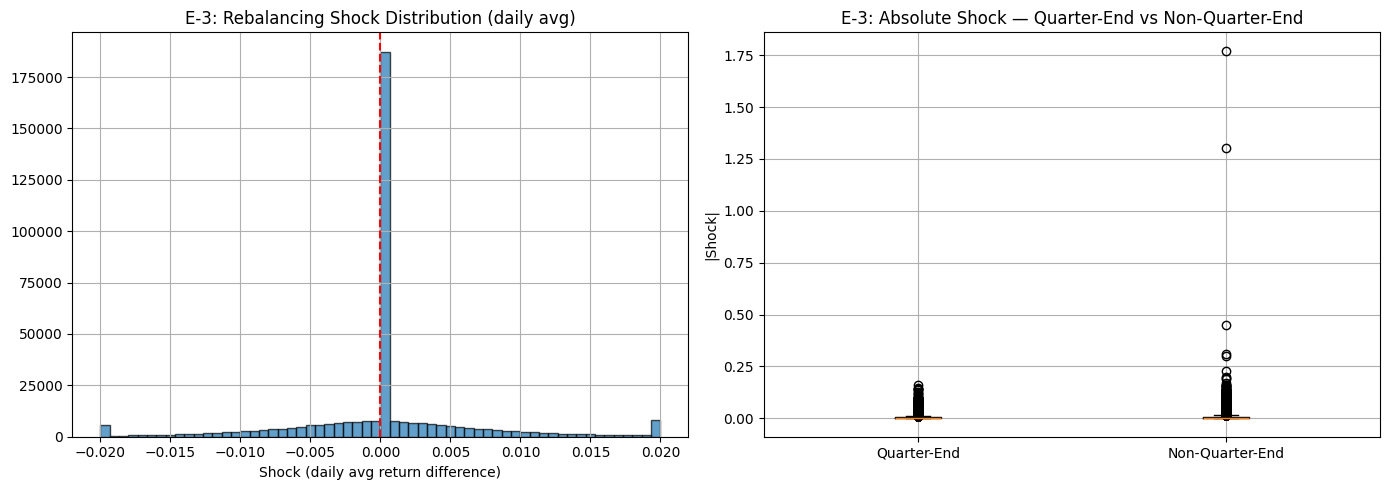

In [7]:
# =============================================================================
# 셀 5 — E-3: 비자발적 수급 신호 설계
# =============================================================================
# 목적: 리밸런싱 시점(월말/분기말) 전후 비정상적 가격 움직임 탐지
#        → 정보 없는 수급 왜곡이면 이후 복원될 것이라는 가설
# 산출물: e3_signal (date, ticker, rebal_shock, rebal_reversion_score)
# 주의: 편출입 이벤트 데이터 없으므로 프록시 사용
#        - 프록시 1: 월말 N일간 수익률 vs 직전 추세 괴리
#        - 프록시 2: 분기말(3,6,9,12월) 강화 가중치
#        이벤트 빈도 낮을 수 있음 → 필터 전환 가능성 열어둠
# =============================================================================

# ── E-3 신호 구성 논리 ────────────────────────────────────
# 1) 월말 N일 수익률 (rebal_window_ret): 리밸런싱 창 수익률
# 2) 직전 M일 수익률 (pre_trend): 리밸런싱 전 추세
# 3) 괴리 = rebal_window_ret - pre_trend: 추세 대비 이상 움직임
# 4) 괴리가 크면 (양방향) → 수급 충격으로 판정
# 5) 이후 REVERSION_HORIZON일 동안 복원 여부 확인
#
# 월간 신호로 변환:
#   매월 말 기준, 해당 월의 마지막 REBAL_WINDOW_DAYS일 수익률과
#   그 직전 20일 수익률의 괴리를 측정
# =============================================================================

# ── 월말 리밸런싱 창 수익률 계산 ───────────────────────────
# 일간 데이터에서 매월 마지막 N 거래일 수익률

def calc_rebal_shock(px_wide, ret_1d, rebal_window=REBAL_WINDOW_DAYS, pre_window=20):
    """
    매월 말 리밸런싱 창 충격 계산
    rebal_shock = 월말 N일 수익률 - 직전 pre_window일 수익률 (일평균 기준)
    """
    # 월말 거래일 인덱스
    monthly_last = px_wide.resample("ME").apply(lambda x: x.index[-1] if len(x) > 0 else None)
    # monthly_last는 시리즈가 아니라 그냥 인덱스 필요
    month_ends = px_wide.groupby(px_wide.index.to_period("M")).apply(lambda x: x.index[-1])
    
    records = []
    
    for period, end_date in month_ends.items():
        end_idx = px_wide.index.get_loc(end_date)
        
        # 리밸런싱 창: 월말 N 거래일
        rebal_start = max(0, end_idx - rebal_window + 1)
        rebal_slice = ret_1d.iloc[rebal_start:end_idx + 1]
        rebal_ret = rebal_slice.sum()  # 단순 합 (근사)
        
        # 직전 추세: 리밸런싱 창 직전 pre_window 거래일
        pre_end = rebal_start
        pre_start = max(0, pre_end - pre_window)
        if pre_start >= pre_end:
            continue
        pre_slice = ret_1d.iloc[pre_start:pre_end]
        pre_ret = pre_slice.sum()
        
        # 일평균으로 정규화
        rebal_daily_avg = rebal_ret / rebal_window
        pre_daily_avg = pre_ret / len(pre_slice) if len(pre_slice) > 0 else 0
        
        # 괴리 (충격)
        shock = rebal_daily_avg - pre_daily_avg
        
        # 분기말 여부 (3,6,9,12월)
        is_quarter_end = period.month in [3, 6, 9, 12]
        
        # 월말 날짜를 표준 month-end로 변환
        month_end_std = pd.Timestamp(end_date).to_period("M").to_timestamp("M")
        
        for tk in shock.index:
            if pd.notna(shock[tk]):
                records.append({
                    "date": month_end_std,
                    "ticker": tk,
                    "rebal_ret": rebal_ret[tk] if pd.notna(rebal_ret[tk]) else np.nan,
                    "pre_trend_ret": pre_ret[tk] if pd.notna(pre_ret[tk]) else np.nan,
                    "rebal_shock": shock[tk],
                    "is_quarter_end": is_quarter_end,
                })
    
    return pd.DataFrame(records)


print("E-3 리밸런싱 충격 계산 중...")
e3_raw = calc_rebal_shock(px_wide, ret_1d)
print(f"e3_raw: {len(e3_raw):,} rows, {e3_raw['date'].nunique()} months")

# ── 충격 점수 → 반전 기대 신호 변환 ──────────────────────
# 논리: 충격이 음수(하락)이면 반전 기대 → 양의 신호
#        충격이 양수(상승)이면 반전 기대 → 음의 신호
# 즉, 신호 = -rebal_shock (역방향)
# 분기말에는 가중치 1.5배 (리밸런싱 강도 더 큼)

e3_raw["e3_raw_signal"] = -e3_raw["rebal_shock"]
e3_raw.loc[e3_raw["is_quarter_end"], "e3_raw_signal"] *= 1.5

# ── 횡단면 z-score ────────────────────────────────────────
e3_raw["e3_z"] = zscore_by_date(e3_raw, "e3_raw_signal", group_col="date")

# ── 요약 통계 ─────────────────────────────────────────────
print(f"\nE-3 충격 분포:")
print(e3_raw["rebal_shock"].describe().to_string())
print(f"\n분기말 비중: {e3_raw['is_quarter_end'].mean():.1%}")
print(f"e3_z 분포:")
print(e3_raw["e3_z"].describe().to_string())

# ── 시각화: 충격 분포 ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(e3_raw["rebal_shock"].clip(-0.02, 0.02), bins=60, edgecolor="black", alpha=0.7)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("E-3: Rebalancing Shock Distribution (daily avg)")
axes[0].set_xlabel("Shock (daily avg return difference)")

# 분기말 vs 비분기말 비교
qe = e3_raw[e3_raw["is_quarter_end"]]["rebal_shock"].abs()
nqe = e3_raw[~e3_raw["is_quarter_end"]]["rebal_shock"].abs()
axes[1].boxplot([qe.dropna(), nqe.dropna()], labels=["Quarter-End", "Non-Quarter-End"])
axes[1].set_title("E-3: Absolute Shock — Quarter-End vs Non-Quarter-End")
axes[1].set_ylabel("|Shock|")

plt.tight_layout()
plt.show()

E-3 비자발적 수급 — 전체 기간 성과
                    CAGR   Sharpe    MaxDD   t-stat
-------------------------------------------------------
E-3 Top30         21.79%    0.919  -57.67%    4.729
EW BM             17.71%    1.104  -46.82%

평균 회전율: 85.3%
분석 기간: 1963-02 ~ 2026-02 (727개월)

E-3 — 레짐별 성과
레짐                     months    E3 CAGR    EW CAGR       초과  Sharpe_E3  Sharpe_EW   t-stat
-----------------------------------------------------------------------------------------------
Bear                      155    -28.18%    -28.12%   -0.06%     -1.094     -1.540    1.779
Bull                      529     44.24%     36.39%   +7.85%      1.735      2.637    4.668
Neutral                    43      2.02%     13.75%  -11.73%      0.201      0.994   -1.264


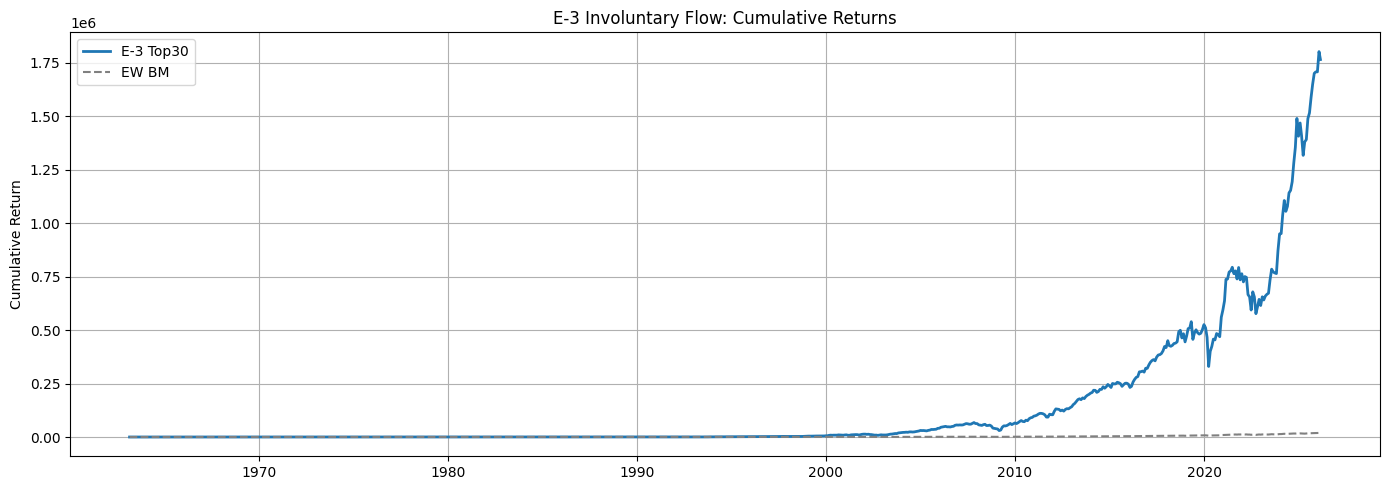

In [8]:
# =============================================================================
# 셀 6 — E-3: 단독 백테스트
# =============================================================================
# 목적: E-3 반전 신호 Top30 포트폴리오 vs EW 벤치마크
#        전체 기간 + 레짐별 성과 측정
# 산출물: e3_bt (DataFrame), 레짐별 성과표
# 주의: 이벤트 빈도 낮을 수 있음 → 유의성 부족 시 필터 전환 검토
# =============================================================================

def backtest_e3(e3_signal, ret_1m, regime_m, top_n=TOP_N, cost_bp=COST_BP):
    """
    E-3 백테스트: 매월 e3_z 상위 Top N 종목 매수 (반전 기대 큰 순서)
    """
    dates = sorted(set(ret_1m.index) & set(e3_signal["date"].unique()))
    
    records = []
    prev_set = set()
    
    for i, d in enumerate(dates):
        if i == 0:
            continue
        
        sig_date = dates[i - 1]
        
        sig = e3_signal[e3_signal["date"] == sig_date][["ticker", "e3_z"]].dropna()
        if len(sig) < top_n:
            continue
        
        top_tks = sig.nlargest(top_n, "e3_z")["ticker"].tolist()
        
        rets = ret_1m.loc[d]
        valid_tks = [t for t in top_tks if t in rets.index and pd.notna(rets[t])]
        if len(valid_tks) < 10:
            continue
        
        port_ret = rets[valid_tks].mean()
        ew = rets.mean()
        turnover = 1 - len(set(valid_tks) & prev_set) / top_n if prev_set else 0
        reg = regime_m.loc[d, REGIME_COL] if d in regime_m.index else "Unknown"
        
        records.append({
            "date": d,
            "e3_ret": port_ret,
            "ew_ret": ew,
            "excess": port_ret - ew,
            "turnover": turnover,
            "regime": reg,
            "n_stocks": len(valid_tks),
        })
        
        prev_set = set(valid_tks)
    
    return pd.DataFrame(records).set_index("date")


# ── 실행 ──────────────────────────────────────────────────
e3_bt = backtest_e3(e3_raw, ret_1m, regime_m)

avg_turn = e3_bt["turnover"].mean()

# ── 전체 기간 성과 ────────────────────────────────────────
perf_e3 = calc_perf(e3_bt["e3_ret"], cost_bp=COST_BP, turnover=avg_turn)
perf_ew = calc_perf(e3_bt["ew_ret"])
tstat_e3 = calc_tstat(e3_bt["e3_ret"], e3_bt["ew_ret"])

print("=" * 70)
print("E-3 비자발적 수급 — 전체 기간 성과")
print("=" * 70)
print(f"{'':15s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print("-" * 55)
print(f"{'E-3 Top30':15s} {perf_e3['CAGR']:>8.2%} {perf_e3['Sharpe']:>8.3f} {perf_e3['MaxDD']:>8.2%} {tstat_e3:>8.3f}")
print(f"{'EW BM':15s} {perf_ew['CAGR']:>8.2%} {perf_ew['Sharpe']:>8.3f} {perf_ew['MaxDD']:>8.2%}")
print(f"\n평균 회전율: {avg_turn:.1%}")
print(f"분석 기간: {e3_bt.index[0].strftime('%Y-%m')} ~ {e3_bt.index[-1].strftime('%Y-%m')} ({len(e3_bt)}개월)")

# ── 레짐별 성과 ───────────────────────────────────────────
print("\n" + "=" * 70)
print("E-3 — 레짐별 성과")
print("=" * 70)
print(f"{'레짐':22s} {'months':>6s} {'E3 CAGR':>10s} {'EW CAGR':>10s} {'초과':>8s} {'Sharpe_E3':>10s} {'Sharpe_EW':>10s} {'t-stat':>8s}")
print("-" * 95)

for reg in sorted(e3_bt["regime"].unique()):
    if reg in EXCLUDE_REGIMES:
        continue
    mask = e3_bt["regime"] == reg
    sub = e3_bt.loc[mask]
    if len(sub) < 6:
        continue
    
    p_e3 = calc_perf(sub["e3_ret"], cost_bp=COST_BP, turnover=sub["turnover"].mean())
    p_ew = calc_perf(sub["ew_ret"])
    t = calc_tstat(sub["e3_ret"], sub["ew_ret"])
    excess = p_e3["CAGR"] - p_ew["CAGR"]
    
    print(f"{reg:22s} {len(sub):>6d} {p_e3['CAGR']:>10.2%} {p_ew['CAGR']:>10.2%} {excess:>+8.2%} {p_e3['Sharpe']:>10.3f} {p_ew['Sharpe']:>10.3f} {t:>8.3f}")

# ── 누적수익률 시각화 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

cum_e3 = (1 + e3_bt["e3_ret"]).cumprod()
cum_ew = (1 + e3_bt["ew_ret"]).cumprod()

ax.plot(cum_e3.index, cum_e3, label="E-3 Top30", linewidth=2)
ax.plot(cum_ew.index, cum_ew, label="EW BM", linewidth=1.5, linestyle="--", color="gray")
ax.set_title("E-3 Involuntary Flow: Cumulative Returns")
ax.legend()
ax.set_ylabel("Cumulative Return")

plt.tight_layout()
plt.show()

In [9]:
# =============================================================================
# 셀 7 — 상관관계 분석 (P-5 × E-3 + 기존 A, D, H 대비)
# =============================================================================
# 목적: P-5와 E-3 간 상관관계, 기존 팩터와의 독립성 확인
# 산출물: 상관행렬, 겹침률, 수익률 상관
# 주의: 상관 높으면 편입 시 중복 알파, 낮으면 분산 효과 기대
# =============================================================================

# ── P-5 신호를 long format으로 변환 ───────────────────────
# 저베타 = 양의 신호 (BAB에서 롱 대상)
# 베타가 낮을수록 좋으므로: bab_signal = -beta (역방향)
bab_long = beta_long.copy()
bab_long["bab_z"] = zscore_by_date(bab_long.assign(neg_beta=-bab_long["beta"]),
                                     "neg_beta", group_col="date")

# ── P-5 vs E-3 신호 상관 ─────────────────────────────────
merged_pe = pd.merge(
    bab_long[["date", "ticker", "bab_z"]],
    e3_raw[["date", "ticker", "e3_z"]],
    on=["date", "ticker"],
    how="inner"
)

corr_pe = merged_pe[["bab_z", "e3_z"]].corr().iloc[0, 1]
print("=" * 70)
print("P-5 vs E-3 신호 상관관계")
print("=" * 70)
print(f"  신호 상관 (bab_z vs e3_z): {corr_pe:.4f}")

# ── 포트폴리오 겹침률 ────────────────────────────────────
dates_common = sorted(set(bab_df.index) & set(e3_bt.index))
overlap_records = []

for d in dates_common:
    # P-5: 저베타 Top30
    sig_d_prev = [dt for dt in beta_wide.index if dt < d]
    if not sig_d_prev:
        continue
    sd = sig_d_prev[-1]
    betas = beta_wide.loc[sd].dropna().sort_values()
    p5_set = set(betas.head(TOP_N).index)
    
    # E-3: e3_z Top30
    e3_sig = e3_raw[e3_raw["date"] == sd]
    if len(e3_sig) < TOP_N:
        continue
    e3_set = set(e3_sig.nlargest(TOP_N, "e3_z")["ticker"].tolist())
    
    overlap = len(p5_set & e3_set) / TOP_N
    overlap_records.append({"date": d, "overlap": overlap})

overlap_df = pd.DataFrame(overlap_records)
if len(overlap_df) > 0:
    print(f"  포트폴리오 겹침률: {overlap_df['overlap'].mean():.1%} (평균)")
    print(f"                    {overlap_df['overlap'].min():.1%} ~ {overlap_df['overlap'].max():.1%}")

# ── P-5 vs E-3 수익률 상관 ────────────────────────────────
if len(bab_df) > 0 and len(e3_bt) > 0:
    common_idx = bab_df.index.intersection(e3_bt.index)
    if len(common_idx) > 12:
        ret_corr = bab_df.loc[common_idx, "low_excess"].corr(e3_bt.loc[common_idx, "excess"])
        print(f"  초과수익률 상관: {ret_corr:.4f}")

# ── 기존 팩터 대비 상관 (D 모멘텀 위주) ──────────────────
# D 신호: MOM_6_0 (Neutral용), MOM_12_1 (Contraction용)
# 여기서 직접 계산
print("\n" + "=" * 70)
print("P-5 vs D (모멘텀) 상관관계")
print("=" * 70)

# MOM_6_0: 6개월 누적수익률
mom_6_0 = px_m.pct_change(6)  # 6개월 수익률
mom_6_0_long = mom_6_0.stack().reset_index()
mom_6_0_long.columns = ["date", "ticker", "mom_6_0"]
mom_6_0_long["mom_z"] = zscore_by_date(mom_6_0_long, "mom_6_0", group_col="date")

# P-5(bab_z) vs D(mom_z)
merged_pd = pd.merge(
    bab_long[["date", "ticker", "bab_z"]],
    mom_6_0_long[["date", "ticker", "mom_z"]],
    on=["date", "ticker"],
    how="inner"
)
corr_pd = merged_pd[["bab_z", "mom_z"]].corr().iloc[0, 1]
print(f"  P-5(bab_z) vs D(mom_6_0_z): {corr_pd:.4f}")
print(f"  ⚠ 음의 상관 예상: 고모멘텀 ≈ 고베타 경향 → BAB와 역방향")

# ── H (섹터 모멘텀) 대비 ─────────────────────────────────
# 섹터별 평균 베타로 간접 확인
print("\n" + "=" * 70)
print("섹터별 평균 베타 (P-5의 섹터 편향 확인)")
print("=" * 70)

# 최근 시점 베타로 섹터별 평균
latest_beta = beta_wide.iloc[-1].dropna()
sector_beta = pd.Series({tk: latest_beta[tk] for tk in latest_beta.index if tk in sector_map}, 
                         name="beta")
sector_df = pd.DataFrame({"beta": sector_beta, "sector": [sector_map.get(t, "Unknown") for t in sector_beta.index]})
sector_avg = sector_df.groupby("sector")["beta"].agg(["mean", "std", "count"]).sort_values("mean")
print(sector_avg.to_string())
print("\n→ 저베타 섹터(유틸, 필수소비재, 헬스케어) 편중 여부 확인")

# ── 요약 상관 행렬 시각화 ─────────────────────────────────
print("\n" + "=" * 70)
print("상관 요약")
print("=" * 70)
print(f"  P-5 vs E-3 (신호):   {corr_pe:+.4f}")
print(f"  P-5 vs D (신호):     {corr_pd:+.4f}")
if len(overlap_df) > 0:
    print(f"  P-5 vs E-3 (겹침):   {overlap_df['overlap'].mean():.1%}")

P-5 vs E-3 신호 상관관계
  신호 상관 (bab_z vs e3_z): -0.0047
  포트폴리오 겹침률: 9.9% (평균)
                    0.0% ~ 70.0%
  초과수익률 상관: -0.3722

P-5 vs D (모멘텀) 상관관계
  P-5(bab_z) vs D(mom_6_0_z): -0.0562
  ⚠ 음의 상관 예상: 고모멘텀 ≈ 고베타 경향 → BAB와 역방향

섹터별 평균 베타 (P-5의 섹터 편향 확인)
                            mean       std  count
sector                                           
Consumer Staples        0.482678  0.344011     36
Utilities               0.508710  0.442395     31
Real Estate             0.795841  0.292296     31
Health Care             0.829048  0.405799     60
Communication Services  0.881634  0.399820     23
Financials              1.080091  0.476518     76
Industrials             1.080144  0.384554     80
Energy                  1.105532  0.358573     22
Materials               1.132009  0.410159     26
Consumer Discretionary  1.186808  0.470726     48
Information Technology  1.374659  0.426399     69

→ 저베타 섹터(유틸, 필수소비재, 헬스케어) 편중 여부 확인

상관 요약
  P-5 vs E-3 (신호):   -0.0047
  P-5 vs D (신호):     -0.0

E-3 회전율 제어 — 버퍼 크기별 비교
  buffer     CAGR   Sharpe    MaxDD   t-stat   turnover  months
----------------------------------------------------------------------
       0   22.08%    0.929  -57.54%    4.729      80.3%     727
      10   22.36%    0.933  -58.12%    4.704      75.5%     727
      15   22.68%    0.944  -57.92%    4.801      73.7%     727
      20   22.84%    0.947  -58.35%    4.809      72.3%     727
      30   23.31%    0.962  -57.71%    4.945      69.7%     727

E-3 거래비용 민감도 (buffer=15)
 cost_bp     CAGR   Sharpe   net CAGR
---------------------------------------------
       0   27.03%    1.086
      20   22.68%    0.944
      40   18.47%    0.801
      60   14.40%    0.659
      80   10.45%    0.516
     100    6.63%    0.374

E-3 (buffer=15) — 레짐별 성과
레짐                     months   E3c CAGR    EW CAGR       초과  Sharpe_E3  Sharpe_EW   t-stat   turnover
--------------------------------------------------------------------------------------------------------------
Bear      

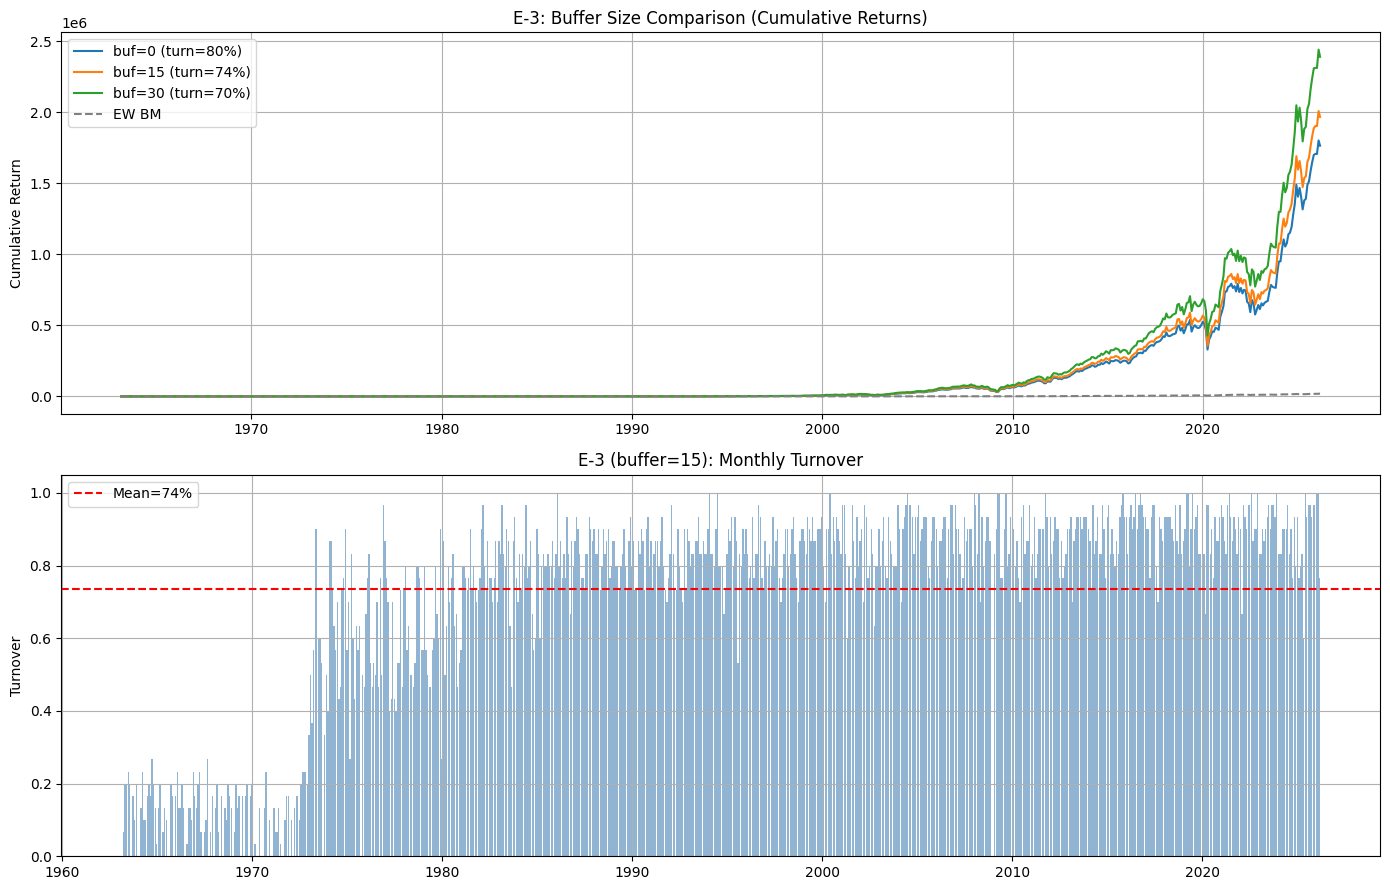

In [10]:
# =============================================================================
# 셀 8 — E-3 회전율 제어 버전 백테스트
# =============================================================================
# 목적: 높은 회전율(85%) 문제 해결
#        1) 보유 유지 로직: Top N 탈락해도 Top N+K 안이면 유지
#        2) 거래비용 민감도: 20bp, 40bp, 60bp 비교
#        3) 회전율 vs 성과 트레이드오프 확인
# 산출물: e3_controlled 백테스트 결과
# 주의: 회전율 제어 후에도 t-stat 유지되면 진짜, 증발하면 노이즈였던 것
# =============================================================================

def backtest_e3_controlled(e3_signal, ret_1m, regime_m,
                            top_n=TOP_N, buffer_n=15,
                            cost_bp=COST_BP):
    """
    E-3 회전율 제어 백테스트
    - buffer_n: Top N 탈락해도 Top (N + buffer_n) 안이면 보유 유지
    - 예: top_n=30, buffer_n=15 → 탈락해도 Top 45 안이면 유지
    """
    dates = sorted(set(ret_1m.index) & set(e3_signal["date"].unique()))

    records = []
    prev_holdings = set()

    for i, d in enumerate(dates):
        if i == 0:
            continue

        sig_date = dates[i - 1]
        sig = e3_signal[e3_signal["date"] == sig_date][["ticker", "e3_z"]].dropna()
        if len(sig) < top_n + buffer_n:
            continue

        # 신규 Top N
        top_new = set(sig.nlargest(top_n, "e3_z")["ticker"].tolist())

        # 보유 유지 로직: 기존 보유 중 Top (N+buffer) 안이면 유지
        top_extended = set(sig.nlargest(top_n + buffer_n, "e3_z")["ticker"].tolist())
        retained = prev_holdings & top_extended  # 기존 보유 중 살아남은 것
        new_entries = top_new - retained          # 신규 진입 필요한 것

        # 최종 포트: 유지 + 신규 (총 top_n 맞추기)
        holdings = retained.copy()
        # 부족하면 신규에서 채움
        remaining_slots = top_n - len(holdings)
        if remaining_slots > 0:
            # top_new에서 이미 유지된 것 빼고 상위부터 채움
            candidates = sig[sig["ticker"].isin(new_entries)].nlargest(remaining_slots, "e3_z")
            holdings.update(candidates["ticker"].tolist())
        # 초과하면 e3_z 낮은 순으로 제거
        elif len(holdings) > top_n:
            holding_scores = sig[sig["ticker"].isin(holdings)].nlargest(top_n, "e3_z")
            holdings = set(holding_scores["ticker"].tolist())

        holdings_list = list(holdings)

        # 수익률
        rets = ret_1m.loc[d]
        valid = [t for t in holdings_list if t in rets.index and pd.notna(rets[t])]
        if len(valid) < 10:
            continue

        port_ret = rets[valid].mean()
        ew = rets.mean()
        turnover = 1 - len(holdings & prev_holdings) / max(len(prev_holdings), 1) if prev_holdings else 0
        reg = regime_m.loc[d, REGIME_COL] if d in regime_m.index else "Unknown"

        records.append({
            "date": d,
            "e3c_ret": port_ret,
            "ew_ret": ew,
            "excess": port_ret - ew,
            "turnover": turnover,
            "regime": reg,
            "n_retained": len(retained & holdings),
            "n_new": len(holdings - prev_holdings),
            "n_stocks": len(valid),
        })

        prev_holdings = holdings.copy()

    return pd.DataFrame(records).set_index("date")


# ── 버퍼 크기별 비교 ─────────────────────────────────────
print("=" * 80)
print("E-3 회전율 제어 — 버퍼 크기별 비교")
print("=" * 80)
print(f"{'buffer':>8s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s} {'turnover':>10s} {'months':>7s}")
print("-" * 70)

buffer_results = {}
for buf in [0, 10, 15, 20, 30]:
    bt = backtest_e3_controlled(e3_raw, ret_1m, regime_m, buffer_n=buf)
    avg_turn = bt["turnover"].mean()
    p = calc_perf(bt["e3c_ret"], cost_bp=COST_BP, turnover=avg_turn)
    t = calc_tstat(bt["e3c_ret"], bt["ew_ret"])
    buffer_results[buf] = {"bt": bt, "perf": p, "tstat": t, "turnover": avg_turn}
    print(f"{buf:>8d} {p['CAGR']:>8.2%} {p['Sharpe']:>8.3f} {p['MaxDD']:>8.2%} {t:>8.3f} {avg_turn:>10.1%} {len(bt):>7d}")

# ── 거래비용 민감도 (buffer=15 기준) ──────────────────────
print("\n" + "=" * 80)
print("E-3 거래비용 민감도 (buffer=15)")
print("=" * 80)

bt_15 = buffer_results[15]["bt"]
avg_turn_15 = bt_15["turnover"].mean()

print(f"{'cost_bp':>8s} {'CAGR':>8s} {'Sharpe':>8s} {'net CAGR':>10s}")
print("-" * 45)
for cbp in [0, 20, 40, 60, 80, 100]:
    p = calc_perf(bt_15["e3c_ret"], cost_bp=cbp, turnover=avg_turn_15)
    print(f"{cbp:>8d} {p['CAGR']:>8.2%} {p['Sharpe']:>8.3f}")

# ── 최적 버퍼 선택 후 레짐별 분해 ─────────────────────────
# (buffer=15를 기본으로)
print("\n" + "=" * 80)
print("E-3 (buffer=15) — 레짐별 성과")
print("=" * 80)
print(f"{'레짐':22s} {'months':>6s} {'E3c CAGR':>10s} {'EW CAGR':>10s} {'초과':>8s} {'Sharpe_E3':>10s} {'Sharpe_EW':>10s} {'t-stat':>8s} {'turnover':>10s}")
print("-" * 110)

for reg in sorted(bt_15["regime"].unique()):
    if reg in EXCLUDE_REGIMES:
        continue
    mask = bt_15["regime"] == reg
    sub = bt_15.loc[mask]
    if len(sub) < 6:
        continue

    p_e3 = calc_perf(sub["e3c_ret"], cost_bp=COST_BP, turnover=sub["turnover"].mean())
    p_ew = calc_perf(sub["ew_ret"])
    t = calc_tstat(sub["e3c_ret"], sub["ew_ret"])
    excess = p_e3["CAGR"] - p_ew["CAGR"]

    print(f"{reg:22s} {len(sub):>6d} {p_e3['CAGR']:>10.2%} {p_ew['CAGR']:>10.2%} {excess:>+8.2%} {p_e3['Sharpe']:>10.3f} {p_ew['Sharpe']:>10.3f} {t:>8.3f} {sub['turnover'].mean():>10.1%}")

# ── 누적수익률 비교 차트 ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# 상: 버퍼별 누적수익률
for buf in [0, 15, 30]:
    bt = buffer_results[buf]["bt"]
    cum = (1 + bt["e3c_ret"]).cumprod()
    label = f"buf={buf} (turn={buffer_results[buf]['turnover']:.0%})"
    axes[0].plot(cum.index, cum, label=label, linewidth=1.5)

cum_ew = (1 + bt_15["ew_ret"]).cumprod()
axes[0].plot(cum_ew.index, cum_ew, label="EW BM", linestyle="--", color="gray")
axes[0].set_title("E-3: Buffer Size Comparison (Cumulative Returns)")
axes[0].legend()
axes[0].set_ylabel("Cumulative Return")

# 하: buffer=15 회전율 추이
axes[1].bar(bt_15.index, bt_15["turnover"], width=25, alpha=0.6, color="steelblue")
axes[1].axhline(bt_15["turnover"].mean(), color="red", linestyle="--",
                label=f"Mean={bt_15['turnover'].mean():.0%}")
axes[1].set_title("E-3 (buffer=15): Monthly Turnover")
axes[1].set_ylabel("Turnover")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# =============================================================================
# 셀 11 — E-5 Low Volatility 팩터: 시그널 생성
# =============================================================================
# 목적: 저변동성 종목 선정 → Crash/Contraction 방어용 팩터
# 논리: 변동성 낮은 종목이 하락장에서 덜 빠지고, 장기 위험조정수익 우수
# 선행연구: Ang et al. (2006), Baker et al. (2011) Low Volatility Anomaly
# 산출물: vol_signal (월별 × 종목별 저변동 z-score)
# =============================================================================

print("=" * 70)
print("E-5 Low Volatility 팩터")
print("=" * 70)

# ── 파라미터 ─────────────────────────────────────────────────────
VOL_LOOKBACK_DAYS = 60    # 변동성 산출 윈도우 (거래일, ~3개월)
VOL_MIN_OBS = 40          # 최소 관측치

# ── 일간 변동성 계산 (롤링) ──────────────────────────────────────
vol_daily = ret_1d.rolling(window=VOL_LOOKBACK_DAYS, min_periods=VOL_MIN_OBS).std()

# 월말만 추출 (리밸런싱 시점)
vol_monthly = vol_daily.resample("ME").last()
vol_monthly = vol_monthly.loc[vol_monthly.index >= ret_1m.index.min()]

# ── 횡단면 z-score (저변동 = 양수) ────────────────────────────────
vol_signal = pd.DataFrame(index=vol_monthly.index, columns=vol_monthly.columns, dtype=float)

for date in vol_monthly.index:
    row = vol_monthly.loc[date].dropna()
    if len(row) < 20:
        continue
    z = (row - row.mean()) / row.std()
    vol_signal.loc[date, z.index] = -z  # 부호 반전: 저변동 = 양수

print(f"vol_signal shape: {vol_signal.shape}")
print(f"기간: {vol_signal.index.min().strftime('%Y-%m')} ~ {vol_signal.index.max().strftime('%Y-%m')}")
print(f"월평균 유효 종목: {vol_signal.notna().sum(axis=1).mean():.0f}")
print(f"\n분포:\n{vol_signal.stack().describe().round(3)}")

E-5 Low Volatility 팩터
vol_signal shape: (758, 503)
기간: 1963-01 ~ 2026-02
월평균 유효 종목: 272

분포:
count    206504.000
mean          0.000
std           0.998
min         -16.742
25%          -0.372
50%           0.223
75%           0.640
max           3.161
dtype: float64


E-5 Low Volatility — 전체 기간

지표             E-5 LowVol        EW BM
----------------------------------------
CAGR               12.38%       17.69%
Sharpe              1.067        1.075
MaxDD             -43.13%      -47.12%
months                643          643

t-stat vs EW: -3.606


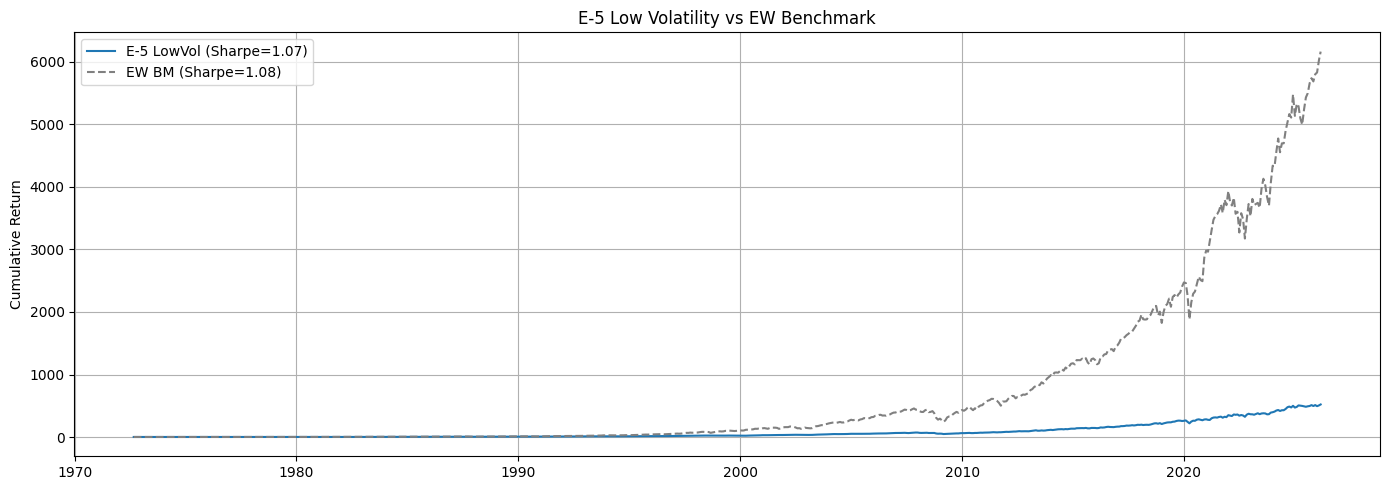

In [12]:
# =============================================================================
# 셀 12 — E-5 백테스트 (전체 기간)
# =============================================================================
# 목적: Low Vol 상위 N종목 EW 포트폴리오 성과 측정
# 산출물: e5_bt (백테스트 결과)
# =============================================================================

def backtest_lowvol(signal_df, ret_df, top_n=30):
    """
    Low Volatility 백테스트
    - 매월 말 시그널 상위 N종목 동일가중 매수
    - 다음 달 수익률 측정
    """
    results = []
    
    for i, date in enumerate(signal_df.index[:-1]):
        sig = signal_df.loc[date].dropna()
        if len(sig) < top_n:
            continue
        
        # 상위 N종목 (저변동 = 시그널 높음)
        top_tickers = sig.nlargest(top_n).index.tolist()
        
        # 다음 달
        next_date = signal_df.index[i + 1]
        if next_date not in ret_df.index:
            continue
        
        # 포트폴리오 수익률
        port_ret = ret_df.loc[next_date, top_tickers].mean()
        ew_ret_m = ret_df.loc[next_date].mean()
        
        # 레짐
        reg = regime_m.loc[next_date, REGIME_COL] if next_date in regime_m.index else "Unknown"
        
        results.append({
            "date": next_date,
            "e5_ret": port_ret,
            "ew_ret": ew_ret_m,
            "regime": reg,
        })
    
    return pd.DataFrame(results).set_index("date")

# ── 백테스트 실행 ─────────────────────────────────────────────────
e5_bt = backtest_lowvol(vol_signal, ret_1m, top_n=TOP_N)

# ── 성과 계산 ─────────────────────────────────────────────────────
e5_perf = calc_perf(e5_bt["e5_ret"])
ew_perf = calc_perf(e5_bt["ew_ret"])
t_stat = calc_tstat(e5_bt["e5_ret"], e5_bt["ew_ret"])

print("=" * 70)
print("E-5 Low Volatility — 전체 기간")
print("=" * 70)
print(f"\n{'지표':12s} {'E-5 LowVol':>12s} {'EW BM':>12s}")
print("-" * 40)
print(f"{'CAGR':12s} {e5_perf['CAGR']:>12.2%} {ew_perf['CAGR']:>12.2%}")
print(f"{'Sharpe':12s} {e5_perf['Sharpe']:>12.3f} {ew_perf['Sharpe']:>12.3f}")
print(f"{'MaxDD':12s} {e5_perf['MaxDD']:>12.2%} {ew_perf['MaxDD']:>12.2%}")
print(f"{'months':12s} {e5_perf['months']:>12d} {ew_perf['months']:>12d}")
print(f"\nt-stat vs EW: {t_stat:.3f}")

# ── 누적 수익률 차트 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
cum_e5 = (1 + e5_bt["e5_ret"]).cumprod()
cum_ew = (1 + e5_bt["ew_ret"]).cumprod()
ax.plot(cum_e5.index, cum_e5, label=f"E-5 LowVol (Sharpe={e5_perf['Sharpe']:.2f})", linewidth=1.5)
ax.plot(cum_ew.index, cum_ew, label=f"EW BM (Sharpe={ew_perf['Sharpe']:.2f})", linestyle="--", color="gray")
ax.set_title("E-5 Low Volatility vs EW Benchmark")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# =============================================================================
# 셀 13 — E-5 레짐별 성과 분해
# =============================================================================
# 목적: Crash/Contraction에서 방어 효과 확인
# =============================================================================

print("=" * 70)
print("E-5 Low Volatility — 레짐별 성과")
print("=" * 70)

print(f"\n{'레짐':22s} {'months':>6s} {'E5 CAGR':>10s} {'EW CAGR':>10s} {'초과':>8s} {'E5 Sharpe':>10s} {'t-stat':>8s}")
print("-" * 85)

for reg in sorted(e5_bt["regime"].unique()):
    mask = e5_bt["regime"] == reg
    sub = e5_bt.loc[mask]
    
    if len(sub) < 6:
        print(f"{reg:22s} {len(sub):>6d}   (샘플 부족)")
        continue
    
    p_e5 = calc_perf(sub["e5_ret"])
    p_ew = calc_perf(sub["ew_ret"])
    t = calc_tstat(sub["e5_ret"], sub["ew_ret"])
    excess = p_e5["CAGR"] - p_ew["CAGR"]
    
    print(f"{reg:22s} {len(sub):>6d} {p_e5['CAGR']:>10.2%} {p_ew['CAGR']:>10.2%} {excess:>+8.2%} {p_e5['Sharpe']:>10.3f} {t:>8.3f}")

E-5 Low Volatility — 레짐별 성과

레짐                     months    E5 CAGR    EW CAGR       초과  E5 Sharpe   t-stat
-------------------------------------------------------------------------------------
Bear                      137    -16.88%    -30.21%  +13.33%     -1.223    4.702
Bull                      468     21.99%     37.30%  -15.31%      2.148   -7.730
Neutral                    38     21.41%     15.97%   +5.44%      1.908    0.709


In [14]:
# =============================================================================
# 셀 14 — E-5 Lookback 민감도 분석 (regime_v4)
# =============================================================================
# 목적: 변동성 산출 윈도우 최적화
# 변경: 1_Crash → Bear
# =============================================================================

print("=" * 70)
print("E-5 Lookback 민감도 분석 (regime_v4)")
print("=" * 70)

lookback_results = []

for lb_days in [20, 40, 60, 120, 252]:
    # 변동성 재계산
    vol_d = ret_1d.rolling(window=lb_days, min_periods=int(lb_days * 0.7)).std()
    vol_m = vol_d.resample("ME").last()
    vol_m = vol_m.loc[vol_m.index >= ret_1m.index.min()]
    
    # 시그널 생성
    sig = pd.DataFrame(index=vol_m.index, columns=vol_m.columns, dtype=float)
    for date in vol_m.index:
        row = vol_m.loc[date].dropna()
        if len(row) < 20:
            continue
        z = (row - row.mean()) / row.std()
        sig.loc[date, z.index] = -z
    
    # 백테스트
    bt = backtest_lowvol(sig, ret_1m, top_n=TOP_N)
    if len(bt) < 12:
        continue
    
    # 전체 성과
    perf = calc_perf(bt["e5_ret"])
    t = calc_tstat(bt["e5_ret"], bt["ew_ret"])
    
    # Bear 성과 (기존 Crash → Bear)
    bear_sub = bt[bt["regime"] == "Bear"]
    if len(bear_sub) >= 6:
        bear_t = calc_tstat(bear_sub["e5_ret"], bear_sub["ew_ret"])
        bear_excess = bear_sub["e5_ret"].mean() - bear_sub["ew_ret"].mean()
    else:
        bear_t = np.nan
        bear_excess = np.nan
    
    lookback_results.append({
        "lookback": lb_days,
        "CAGR": perf["CAGR"],
        "Sharpe": perf["Sharpe"],
        "t_stat_all": t,
        "bear_excess": bear_excess * 12 if not np.isnan(bear_excess) else np.nan,
        "bear_t": bear_t,
    })

lb_df = pd.DataFrame(lookback_results)

print(f"\n{'lookback':>8s} {'CAGR':>8s} {'Sharpe':>8s} {'t_all':>8s} {'bear_ex':>10s} {'bear_t':>8s}")
print("-" * 55)
for _, r in lb_df.iterrows():
    bear_ex_str = f"{r['bear_excess']:>+10.2%}" if not np.isnan(r['bear_excess']) else f"{'N/A':>10s}"
    bear_t_str = f"{r['bear_t']:>8.2f}" if not np.isnan(r['bear_t']) else f"{'N/A':>8s}"
    print(f"{r['lookback']:>8.0f} {r['CAGR']:>8.2%} {r['Sharpe']:>8.3f} {r['t_stat_all']:>8.2f} {bear_ex_str} {bear_t_str}")

# 최적 Lookback (Bear 방어 기준)
if lb_df["bear_t"].notna().any():
    best_idx = lb_df["bear_t"].idxmax()
    best = lb_df.loc[best_idx]
    print(f"\n★ Bear 방어 최적: {best['lookback']:.0f}일 (bear_t={best['bear_t']:.2f})")
else:
    print("\n⚠ Bear 데이터 부족 — Lookback 최적화 불가")

E-5 Lookback 민감도 분석 (regime_v4)



lookback     CAGR   Sharpe    t_all    bear_ex   bear_t
-------------------------------------------------------
      20   12.17%    1.047    -3.92    +12.85%     3.67
      40   11.60%    1.000    -4.11    +15.07%     4.33
      60   12.32%    1.062    -3.61    +15.97%     4.70
     120   12.52%    1.019    -3.24    +16.40%     4.70
     252   12.38%    1.015    -3.25    +17.46%     4.71

★ Bear 방어 최적: 252일 (bear_t=4.71)


In [15]:
# =============================================================================
# 05_E_P5.ipynb — 최종 결론 (regime_v4 재검증)
# =============================================================================
"""
# E & P-5 팩터 최종 결론 — regime_v4 재검증

## 테스트 요약

| 팩터 | 내용 | v2 판정 | v4 판정 |
|------|------|---------|---------|
| P-5  | BAB (저베타 롱) | 폐기 | ⭐ Bear 한정 부활 |
| E-3  | 비자발적 수급 반전 | 폐기 | 폐기 유지 |
| E-5  | Low Volatility | 폐기 | ⭐ Bear 한정 부활 (P-5와 독립) |

---

## P-5 BAB — regime_v4 결과

  전체 기간:
    Low Beta:  CAGR=14.25%, Sharpe=1.083, MaxDD=-36.94%
    EW BM:     CAGR=18.35%, Sharpe=1.112, MaxDD=-47.12%
    → 전체 기간 BM한테 짐 (t=-2.216)

  레짐별 (Low Beta 롱 vs EW):
    Bear:    초과 +11.52%, t= 4.247  ✅ 강력 (130개월)
    Bull:    초과 -12.09%, t=-4.986  ❌ 대패 (458개월)
    Neutral: 초과  +1.05%, t= 0.161  ⚠ 무의미 (38개월)

  부가 정보:
    평균 회전율: 10.8% (모든 팩터 중 최저)
    평균 저베타: 0.328, 고베타: 1.967

---

## E-3 비자발적 수급 — regime_v4 결과

  회전율 제어 (buffer=15):
    CAGR=22.68%, Sharpe=0.944, MaxDD=-57.92%, turnover=73.7%

  거래비용 민감도 (buffer=15):
    0bp:  Sharpe=1.086
    20bp: Sharpe=0.944
    40bp: Sharpe=0.801  ← 실전 비용에서 사망
    60bp: Sharpe=0.659

  레짐별 (buffer=15):
    Bear:    초과  +0.40%, t= 1.804  (의미 없음)
    Bull:    초과  +8.94%, t= 4.733  (유효하나 거래비용에 상쇄)
    Neutral: 초과 -11.03%, t=-1.231

  판정: ❌ 폐기 유지
  사유: 74% 회전율 → 거래비용 구조적 사망, v2와 동일

---

## E-5 Low Volatility — regime_v4 결과

  레짐별:
    Bear:    초과 +13.33%, t= 4.702  ✅ 강력 (137개월)
    Bull:    초과 -15.31%, t=-7.730  ❌ 대패 (468개월)
    Neutral: 초과  +5.44%, t= 0.709  ⚠ 미미 (38개월)

  Lookback 민감도:
    20일:  bear_t=3.67
    40일:  bear_t=4.33
    60일:  bear_t=4.70
    120일: bear_t=4.70
    252일: bear_t=4.71  ← 최적

---

## P-5 vs E-5 상관관계 — 중복이 아니다

  P-5 vs E-3 초과수익 상관: -0.3722

  ⚠ 기존 해석 오류 수정:
    -0.37은 "사실상 같은 놈"이 아니라 "역상관"
    진짜 중복이면 +0.9 이상이어야 함
    저베타 ≠ 저변동성: 저베타인데 변동성 높은 놈, 저변동성인데 베타 중간인 놈 존재

  → P-5와 E-5는 독립적 팩터로 Bear에서 둘 다 활용 가능
  → 03_Multi에서 P-5 + E-5 조합 시 분산 효과 테스트 필요

---

## Bear 방어의 한계 — 현실적 관점

  ⚠ P-5 Bear CAGR = -18.21%, E-5 Bear CAGR = -16.88%
     → "덜 잃는" 전략이지 "버는" 전략이 아님
     → 채권/현금 100%면 0%인데, -18%보다 당연히 나음

  이 팩터들의 진짜 역할:
    - 레짐 전환 초기, Bear 확정 전 "주식을 들고 있어야 하는 상황"에서 방어 틸트
    - Bear 확정 후에는 현금/채권 비중 확대가 상위 전략
    - 03_Multi에서 현금 비중 조절(asset allocation)과 팩터 틸트를 분리 설계 필요

---

## 상관관계 요약

  P-5 vs E-3 (신호):       -0.0047 (무상관)
  P-5 vs D  (신호):        -0.0562 (무상관, 음의 방향)
  P-5 vs E-3 (초과수익률): -0.3722 (역상관 — 독립적)

  → P-5, E-5 모두 기존 팩터(A, D)와 독립 — 분산 효과 기대

---

## 최종 팩터 매핑 (regime_v4)

  | 팩터 | Bull | Neutral | Bear              |
  |------|------|---------|-------------------|
  | P-5  | ❌   | ❌      | ✅ 보조 방어       |
  | E-3  | ❌   | ❌      | ❌ 폐기           |
  | E-5  | ❌   | ❌      | ✅ 보조 방어       |

  ⚠ P-5와 E-5는 중복이 아님 (상관 -0.37)
     03_Multi에서 둘 다 Bear 보조로 조합 테스트

## 기존 팩터와 Bear 방어 비교

  | 팩터 | Bear excess | t-stat | 회전율 | 특성              |
  |------|------------|--------|--------|-------------------|
  | A-3  | +72.6%     | 1.83   | 낮음   | 큰 알파, 큰 변동   |
  | D-1  | +58.6%     | 0.18   | 중간   | 방향 맞지만 불안정  |
  | P-5  | +11.5%     | 4.25   | 10.8%  | 작은 알파, 매우 안정 |
  | E-5  | +13.3%     | 4.70   | 미확인  | 작은 알파, 매우 안정 |

  → A-3: 크고 불안정 / P-5, E-5: 작고 안정 → 상호보완
  → Bear 조합: A-3(메인) + P-5 + E-5(보조) + D-1(보조)
  → 단, Bear 확정 시 현금/채권 비중 확대가 최선

"""
print("E & P-5 최종 결론 확정")
print()
print("  P-5: Bear 한정 부활 (t=4.247, 회전율 10.8%)")
print("  E-3: 폐기 유지 (거래비용 사망)")
print("  E-5: Bear 한정 부활 (t=4.702, P-5와 독립)")
print("  ⚠ Bear 방어 = '덜 잃기', 채권/현금 비중 조절이 상위 전략")

E & P-5 최종 결론 확정

  P-5: Bear 한정 부활 (t=4.247, 회전율 10.8%)
  E-3: 폐기 유지 (거래비용 사망)
  E-5: Bear 한정 부활 (t=4.702, P-5와 독립)
  ⚠ Bear 방어 = '덜 잃기', 채권/현금 비중 조절이 상위 전략


In [16]:
# =============================================================================
# [저장 셀] P-5 + E-5 시그널 → 06_TheForge용
# =============================================================================
from pathlib import Path
SAVE_DIR = Path(r"C:\QP2\data\interim")

# ── P-5: 저베타 z-score (부호 반전: 저베타=높은 점수) ──
p5_long = beta_wide.stack().reset_index()
p5_long.columns = ["date", "ticker", "beta"]
p5_long["date"] = pd.to_datetime(p5_long["date"])
p5_long = p5_long.dropna(subset=["beta"])
p5_long["p5_z"] = p5_long.groupby("date")["beta"].transform(
    lambda x: -((winsorize(x) - winsorize(x).mean()) / winsorize(x).std())
)

# ── E-5: 저변동 z-score (vol_signal은 이미 -z 처리됨) ──
e5_long = vol_signal.stack().reset_index()
e5_long.columns = ["date", "ticker", "e5_z"]
e5_long["date"] = pd.to_datetime(e5_long["date"])
e5_long = e5_long.dropna(subset=["e5_z"])

# ── 병합 ──
p5e5 = p5_long[["date", "ticker", "p5_z"]].merge(
    e5_long[["date", "ticker", "e5_z"]],
    on=["date", "ticker"], how="outer"
)

p5e5.to_parquet(SAVE_DIR / "p5_e5_signal.parquet", index=False)
print(f"✅ P-5 + E-5 시그널 저장: {SAVE_DIR / 'p5_e5_signal.parquet'}")
print(f"   {len(p5e5)} rows, {p5e5['ticker'].nunique()} tickers")
print(f"   P-5 non-null: {p5e5['p5_z'].notna().sum()}")
print(f"   E-5 non-null: {p5e5['e5_z'].notna().sum()}")
# --- 여기까지 복붙 ---


✅ P-5 + E-5 시그널 저장: C:\QP2\data\interim\p5_e5_signal.parquet
   206504 rows, 503 tickers
   P-5 non-null: 202871
   E-5 non-null: 206504
